In [3]:
# ==========================================
# CELL 1: CÀI ĐẶT THƯ VIỆN VÀ KẾT NỐI DRIVE
# ==========================================
!pip install torchaudio librosa soundfile torch-audiomentations -q
!pip install tqdm
import os
import random
import numpy as np
import librosa
import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Cố định seed để đảm bảo train lại kết quả không bị thay đổi ngẫu nhiên
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 2. Kết nối Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ==========================================
# CELL 1: CÀI ĐẶT THƯ VIỆN VÀ KẾT NỐI DRIVE
# ==========================================

# 3. Cấu hình đường dẫn (Hãy đảm bảo đường dẫn này đúng với Drive của bạn)
PROJECT_DIR = '/content/drive/My Drive/AI_Conductor_Project'
DATA_DIR = os.path.join(PROJECT_DIR, 'dataset_audio', 'raw')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')

os.makedirs(MODEL_DIR, exist_ok=True)

# 4. Cấu hình Audio chuẩn (Khớp với code ESP32 và Python thu thập của bạn)
SAMPLE_RATE = 16000
DURATION = 1.0 # 1 giây
NUM_SAMPLES = int(SAMPLE_RATE * DURATION)

# Kiểm tra GPU (Bắt buộc phải bật GPU trên Colab: Runtime -> Change runtime type -> T4 GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 AI đang chạy trên thiết bị: {device.type.upper()}")

🚀 AI đang chạy trên thiết bị: CUDA


📊 BẮT ĐẦU PHÂN TÍCH DỮ LIỆU (EDA)...


/tmp/ipykernel_1041/262714027.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')


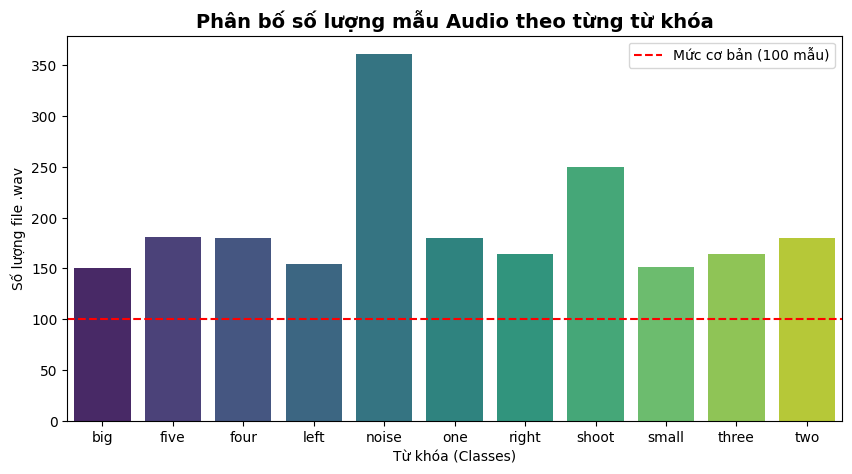


💡 NHẬN XÉT TIỀN XỬ LÝ TỪ EDA:
- Dữ liệu có sự chênh lệch (Imbalanced Data). Tập 'shoot' có nhiều hơn các tập khác.
- Đã cấu hình Stratified Split (chia đều tỷ lệ) trong hàm train_test_split để tránh thiên vị.


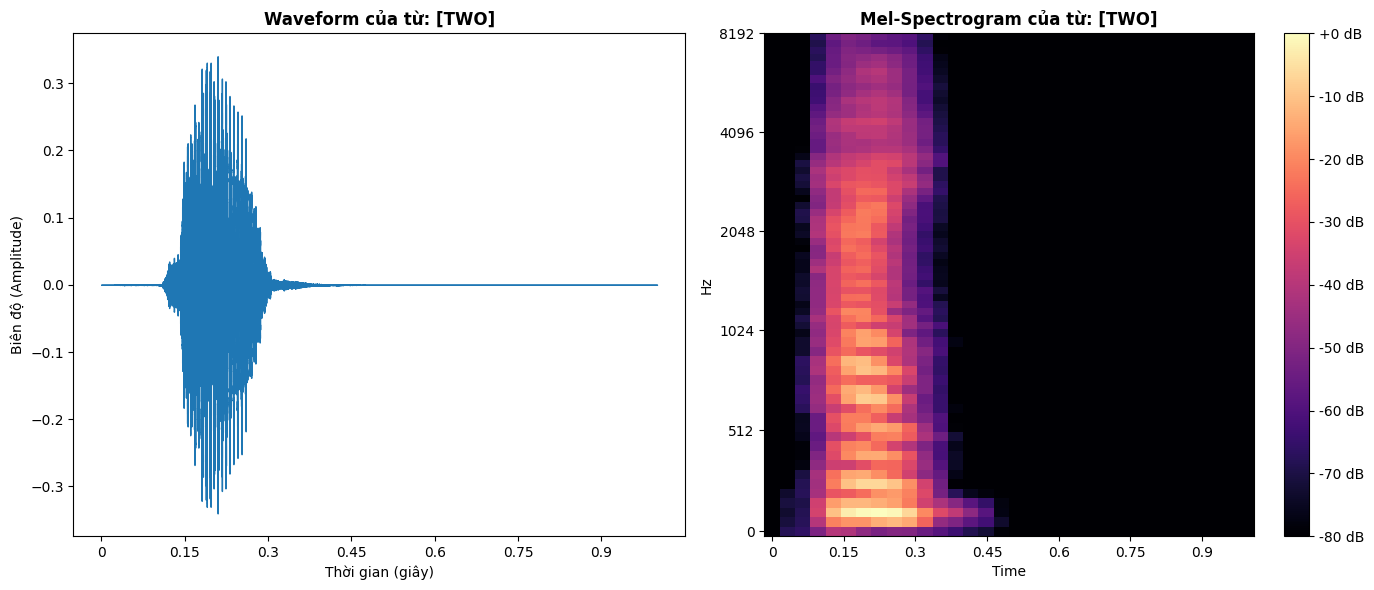

In [5]:
# ==========================================
# CELL 1.5: EDA - KHÁM PHÁ DỮ LIỆU ÂM THANH
# ==========================================
import librosa
import librosa.display
import pandas as pd

print("📊 BẮT ĐẦU PHÂN TÍCH DỮ LIỆU (EDA)...")

# 1. Thống kê số lượng mẫu của từng class
class_counts = {}
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])

for cls_name in classes:
    cls_dir = os.path.join(DATA_DIR, cls_name)
    num_files = len([f for f in os.listdir(cls_dir) if f.endswith('.wav')])
    class_counts[cls_name] = num_files

# Vẽ biểu đồ phân bố dữ liệu
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
plt.title('Phân bố số lượng mẫu Audio theo từng từ khóa', fontsize=14, fontweight='bold')
plt.xlabel('Từ khóa (Classes)')
plt.ylabel('Số lượng file .wav')
plt.axhline(y=100, color='r', linestyle='--', label='Mức cơ bản (100 mẫu)')
plt.legend()
plt.show()

print("\n💡 NHẬN XÉT TIỀN XỬ LÝ TỪ EDA:")
print("- Dữ liệu có sự chênh lệch (Imbalanced Data). Tập 'shoot' có nhiều hơn các tập khác.")
print("- Đã cấu hình Stratified Split (chia đều tỷ lệ) trong hàm train_test_split để tránh thiên vị.")

# 2. Trực quan hóa một mẫu âm thanh ngẫu nhiên
sample_class = random.choice(classes)
sample_dir = os.path.join(DATA_DIR, sample_class)
sample_file = random.choice([f for f in os.listdir(sample_dir) if f.endswith('.wav')])
sample_path = os.path.join(sample_dir, sample_file)

# Đọc bằng librosa để vẽ đẹp hơn
y, sr = librosa.load(sample_path, sr=SAMPLE_RATE)

plt.figure(figsize=(14, 6))

# Đồ thị 1: Sóng âm thanh nguyên bản (Waveform)
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr, color='#1f77b4')
plt.title(f'Waveform của từ: [{sample_class.upper()}]', fontweight='bold')
plt.xlabel('Thời gian (giây)')
plt.ylabel('Biên độ (Amplitude)')

# Đồ thị 2: Mel-Spectrogram (Cái mà Mạng Nơ-ron sẽ thực sự nhìn thấy)
plt.subplot(1, 2, 2)
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel-Spectrogram của từ: [{sample_class.upper()}]', fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# CELL 2: LỚP XỬ LÝ DATA AUGMENTATION (ĐÃ FIX CUDA MULTIPROCESSING LỖI)
# ==========================================

class AudioAugmenter:
    def __init__(self, sample_rate=16000):
        self.sample_rate = sample_rate

        # CHÚ Ý: Đã bỏ toàn bộ .to(device) ở đây để các CPU Workers tự do xử lý song song
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=self.sample_rate,
            n_fft=1024,
            win_length=None,
            hop_length=512,
            center=True,
            pad_mode="reflect",
            power=2.0,
            norm='slaney',
            n_mels=64,
            mel_scale="htk",
        )

        self.amplitude_to_db = T.AmplitudeToDB()
        self.freq_masking = T.FrequencyMasking(freq_mask_param=15)
        self.time_masking = T.TimeMasking(time_mask_param=25)

    def add_white_noise(self, waveform, noise_level=0.02):
        noise = torch.randn_like(waveform) * noise_level
        return waveform + noise

    def time_shift(self, waveform, shift_limit=0.1):
        shift_amt = int(random.uniform(-shift_limit, shift_limit) * self.sample_rate)
        return torch.roll(waveform, shifts=shift_amt, dims=1)

    def change_volume(self, waveform, gain_limit=2.0):
        gain = random.uniform(0.5, gain_limit)
        return waveform * gain

    def process(self, waveform, is_train=False):
        """Pipeline xử lý từ sóng âm thanh (Waveform) -> Ảnh Mel-Spectrogram hoàn toàn trên CPU"""
        # CHÚ Ý: Đã xóa dòng waveform = waveform.to(device)

        if is_train:
            # 1. Data Augmentation trên Waveform thô
            if random.random() < 0.5:
                waveform = self.add_white_noise(waveform, noise_level=random.uniform(0.005, 0.02))
            if random.random() < 0.5:
                waveform = self.time_shift(waveform)
            if random.random() < 0.5:
                waveform = self.change_volume(waveform)

        # 2. Chuyển đổi sang Mel-Spectrogram
        mel_spec = self.mel_spectrogram(waveform)
        mel_spec = self.amplitude_to_db(mel_spec)

        if is_train:
            # 3. Data Augmentation trên ảnh Spectrogram (SpecAugment)
            if random.random() < 0.5:
                mel_spec = self.freq_masking(mel_spec)
            if random.random() < 0.5:
                mel_spec = self.time_masking(mel_spec)

        # 4. Chuẩn hóa (Normalize)
        mean = mel_spec.mean()
        std = mel_spec.std()
        mel_spec = (mel_spec - mean) / (std + 1e-6)

        return mel_spec

print("✅ Đã khởi tạo thành công bộ Audio Augmenter (CPU mode - An toàn cho DataLoader)!")

✅ Đã khởi tạo thành công bộ Audio Augmenter (CPU mode - An toàn cho DataLoader)!


In [8]:
# ==========================================
# CELL 3: DATASET VÀ QUẢN LÝ DỮ LIỆU
# ==========================================

class AudioDataset(Dataset):
    def __init__(self, file_paths, labels, label_to_idx, augmenter, is_train=True):
        self.file_paths = file_paths
        self.labels = labels
        self.label_to_idx = label_to_idx
        self.augmenter = augmenter
        self.is_train = is_train

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label_name = self.labels[idx]
        label_idx = self.label_to_idx[label_name]

        # Đọc file audio (.wav)
        waveform, sr = torchaudio.load(path)

        # Đảm bảo là Mono (1 kênh)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # Resample nếu lỡ file thu không đúng 16kHz
        if sr != SAMPLE_RATE:
            resampler = T.Resample(orig_freq=sr, new_freq=SAMPLE_RATE)
            waveform = resampler(waveform)

        # Padding hoặc Truncating để đảm bảo ĐÚNG 16000 mẫu (1 giây)
        if waveform.shape[1] < NUM_SAMPLES:
            # Bù số 0 (im lặng) vào cuối nếu bị thiếu
            pad_length = NUM_SAMPLES - waveform.shape[1]
            waveform = F.pad(waveform, (0, pad_length))
        elif waveform.shape[1] > NUM_SAMPLES:
            # Cắt bớt nếu bị thừa
            waveform = waveform[:, :NUM_SAMPLES]

        # Áp dụng Data Augmentation và chuyển thành Mel-Spectrogram
        mel_spec = self.augmenter.process(waveform, is_train=self.is_train)

        # Bỏ đi batch dimension thừa từ augmenter, trả về dạng (1, n_mels, time_frames)
        mel_spec = mel_spec.squeeze(0)

        return mel_spec, torch.tensor(label_idx, dtype=torch.long)

# ---- QUÉT THƯ MỤC VÀ CHUẨN BỊ DỮ LIỆU ----
print("🔍 Đang quét thư mục dữ liệu...")
all_files = []
all_labels = []

# Lấy danh sách các thư mục con (chính là tên các từ khóa: 'shoot', 'one', 'two'...)
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
label_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
idx_to_label = {i: cls_name for cls_name, i in label_to_idx.items()}

for cls_name in classes:
    cls_dir = os.path.join(DATA_DIR, cls_name)
    files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.endswith('.wav')]
    all_files.extend(files)
    all_labels.extend([cls_name] * len(files))
    print(f"  📁 Lớp '{cls_name}': {len(files)} files")

print(f"✅ Tổng cộng: {len(all_files)} files | {len(classes)} classes: {classes}")

# Chia tập Train (80%) và Validation (20%) có cân bằng nhãn (stratify)
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    all_files, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

# Khởi tạo Augmenter và Dataset
augmenter = AudioAugmenter(SAMPLE_RATE)
train_dataset = AudioDataset(X_train_paths, y_train, label_to_idx, augmenter, is_train=True)
val_dataset = AudioDataset(X_val_paths, y_val, label_to_idx, augmenter, is_train=False)

# Tạo DataLoader để train theo từng Batch (Gói)
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"📦 Đã tạo DataLoader: BATCH_SIZE = {BATCH_SIZE}")

🔍 Đang quét thư mục dữ liệu...
  📁 Lớp 'big': 150 files
  📁 Lớp 'five': 181 files
  📁 Lớp 'four': 180 files
  📁 Lớp 'left': 154 files
  📁 Lớp 'noise': 361 files
  📁 Lớp 'one': 180 files
  📁 Lớp 'right': 164 files
  📁 Lớp 'shoot': 250 files
  📁 Lớp 'small': 151 files
  📁 Lớp 'three': 164 files
  📁 Lớp 'two': 180 files
✅ Tổng cộng: 2115 files | 11 classes: ['big', 'five', 'four', 'left', 'noise', 'one', 'right', 'shoot', 'small', 'three', 'two']
📦 Đã tạo DataLoader: BATCH_SIZE = 32


In [9]:
# ==========================================
# CELL 4: KIẾN TRÚC MẠNG NƠ-RON SIÊU CẤP
# ==========================================

class AudioAttention(nn.Module):
    def __init__(self, hidden_size):
        super(AudioAttention, self).__init__()
        # Attention layer đánh giá tầm quan trọng của từng mốc thời gian
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1, bias=False)
        )

    def forward(self, lstm_outputs):
        # lstm_outputs shape: (Batch, Time, Hidden)
        attn_weights = self.attention(lstm_outputs) # (Batch, Time, 1)
        attn_weights = F.softmax(attn_weights, dim=1) # Chuẩn hóa thành xác suất

        # Nhân trọng số attention với output của LSTM
        context_vector = torch.sum(attn_weights * lstm_outputs, dim=1) # (Batch, Hidden)
        return context_vector, attn_weights

class KeywordSpottingNet(nn.Module):
    def __init__(self, num_classes):
        super(KeywordSpottingNet, self).__init__()

        # Khối 1: Trích xuất đặc trưng hình ảnh của âm thanh (Mel-Spectrogram) bằng CNN
        # Input shape: (Batch, 1, 64 (Mels), Time)
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2)), # Giảm Mels xuống 32

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2)), # Giảm Mels xuống 16

            nn.Dropout2d(0.2)
        )

        # Sau 2 lần MaxPool, chiều cao (Mels) từ 64 -> 32 -> 16.
        # Số kênh CNN là 32. Tính tổng Features đầu vào cho LSTM: 16 * 32 = 512
        lstm_input_size = 16 * 32

        # Khối 2: Xử lý chuỗi thời gian bằng Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        # Khối 3: Attention Focus (BiLSTM có 2 chiều nên hidden_size = 64 * 2 = 128)
        self.attention = AudioAttention(hidden_size=128)

        # Khối 4: Phân loại cuối cùng
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, 1, Mels, Time)
        x = self.cnn(x)

        # Chuẩn bị dữ liệu cho LSTM: Gộp kênh (Channel) và tần số (Mels) lại
        # x đang là: (Batch, Channels(32), Mels(16), Time)
        # Cần chuyển đổi thành: (Batch, Time, Features)
        batch_size, channels, mels, time_frames = x.size()
        x = x.permute(0, 3, 1, 2).contiguous() # -> (Batch, Time, Channels, Mels)
        x = x.view(batch_size, time_frames, channels * mels) # -> (Batch, Time, 512)

        # Chạy qua LSTM
        lstm_out, _ = self.lstm(x)

        # Áp dụng Attention để tìm vùng âm thanh quan trọng nhất
        context_vector, attn_weights = self.attention(lstm_out)

        # Phân loại
        out = self.classifier(context_vector)
        return out

# Khởi tạo Mô hình
num_classes = len(classes)
model = KeywordSpottingNet(num_classes=num_classes).to(device)

print(f"🧠 Đã khởi tạo AI Model! Có khả năng nhận diện {num_classes} từ khóa.")
# Thử chạy qua 1 Batch ảo để đảm bảo code không có lỗi Dimension (Chiều dữ liệu)
dummy_input = torch.randn(2, 1, 64, 32).to(device) # Giả lập 2 mẫu âm thanh
dummy_output = model(dummy_input)
print(f"✅ Pass kiểm tra chiều dữ liệu! Model Output Shape: {dummy_output.shape}")

🧠 Đã khởi tạo AI Model! Có khả năng nhận diện 11 từ khóa.
✅ Pass kiểm tra chiều dữ liệu! Model Output Shape: torch.Size([2, 11])


In [10]:
# ==========================================
# CELL 5: QUÁ TRÌNH HUẤN LUYỆN (TRAINING LOOP) - TÍCH HỢP TQDM & F1-SCORE
# ==========================================
import copy
from tqdm import tqdm
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

EPOCHS = 100
LEARNING_RATE = 0.001
PATIENCE = 15 # Nếu sau 15 Epochs mà không tiến bộ thì dừng
# Bước 1: Tính toán trọng số tự động dựa trên số lượng mẫu thực tế
# Lớp nào ít mẫu -> Trọng số cao (Phạt nặng nếu AI đoán sai)
# Lớp nào nhiều mẫu (như Noise 361) -> Trọng số thấp (Phạt nhẹ hơn)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Bước 2: Chuyển mảng trọng số thành Tensor và đẩy lên GPU
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32).to(device)

# Bước 3: Gắn trọng số này vào hàm CrossEntropyLoss
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
# ---------------------------------------------------------

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Lịch sử để vẽ biểu đồ (Bổ sung thêm F1)
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': []
}

best_val_loss = float('inf')
best_model_weights = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

print("🔥 BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH AI AUDIO...")
print("-" * 80)

for epoch in range(EPOCHS):
    # ================= 1. TRAIN PHASE =================
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    all_train_preds = []
    all_train_targets = []

    # Bọc DataLoader bằng tqdm để tạo thanh tiến trình
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:03d}/{EPOCHS} [Train]", leave=False, bar_format='{l_bar}{bar:20}{r_bar}')

    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = inputs.unsqueeze(1) # (Batch, 1, Mels, Time)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)

        correct_train += torch.sum(preds == labels.data).item()
        total_train += labels.size(0)

        # Gom dự đoán để tính F1
        all_train_preds.extend(preds.cpu().numpy())
        all_train_targets.extend(labels.cpu().numpy())

        # Cập nhật thanh tiến trình theo thời gian thực
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train * 100
    epoch_train_f1 = f1_score(all_train_targets, all_train_preds, average='weighted')

    # ================= 2. VALIDATION PHASE =================
    model.eval()
    running_loss_val = 0.0
    correct_val = 0
    total_val = 0

    all_val_preds = []
    all_val_targets = []

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1:03d}/{EPOCHS} [Val]  ", leave=False, bar_format='{l_bar}{bar:20}{r_bar}')

    with torch.no_grad():
        for inputs, labels in val_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss_val += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)

            correct_val += torch.sum(preds == labels.data).item()
            total_val += labels.size(0)

            all_val_preds.extend(preds.cpu().numpy())
            all_val_targets.extend(labels.cpu().numpy())

    epoch_val_loss = running_loss_val / total_val
    epoch_val_acc = correct_val / total_val * 100
    epoch_val_f1 = f1_score(all_val_targets, all_val_preds, average='weighted')

    # Lưu lịch sử
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    history['train_f1'].append(epoch_train_f1)
    history['val_f1'].append(epoch_val_f1)

    # Cập nhật Scheduler
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(epoch_val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    # In báo cáo của Epoch ra màn hình (rất gọn gàng và tường minh)
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"TRAIN: Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc:5.2f}% - F1: {epoch_train_f1:.4f} | "
          f"VAL: Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:5.2f}% - F1: {epoch_val_f1:.4f}")

    if new_lr < current_lr:
        print(f"   ↳ 📉 [LR Scheduler] Giảm Learning Rate xuống {new_lr} để dò đáy Loss.")

    # ================= 3. EARLY STOPPING & LƯU MODEL =================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print(f"   ↳ 🌟 [New Best] Mô hình đã được cập nhật!")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"\n🛑 Kích hoạt Early Stopping ở Epoch {epoch+1}! Mô hình không cải thiện sau {PATIENCE} vòng lặp.")
        break

# Khôi phục trọng số tốt nhất
model.load_state_dict(best_model_weights)
print("-" * 80)
print(f"🏆 HUẤN LUYỆN HOÀN TẤT! Best Validation Loss: {best_val_loss:.4f}")

# LƯU FILE LÊN GOOGLE DRIVE
SAVE_PATH = os.path.join(MODEL_DIR, "best_audio_model.pth")
checkpoint = {
    'model_state_dict': model.state_dict(),
    'label_mapping': idx_to_label,
    'num_classes': num_classes
}
torch.save(checkpoint, SAVE_PATH)
print(f"💾 Đã lưu File Model vĩnh viễn tại: {SAVE_PATH}")

🔥 BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH AI AUDIO...
--------------------------------------------------------------------------------


Epoch 001/100 | TRAIN: Loss: 2.4511 - Acc: 11.35% - F1: 0.1117 | VAL: Loss: 2.1965 - Acc: 31.68% - F1: 0.2479
   ↳ 🌟 [New Best] Mô hình đã được cập nhật!


Epoch 002/100 | TRAIN: Loss: 2.3277 - Acc: 15.54% - F1: 0.1533 | VAL: Loss: 1.9930 - Acc: 28.84% - F1: 0.2479
   ↳ 🌟 [New Best] Mô hình đã được cập nhật!


Epoch 003/100 | TRAIN: Loss: 2.2350 - Acc: 17.43% - F1: 0.1701 | VAL: Loss: 1.8614 - Acc: 37.12% - F1: 0.3551
   ↳ 🌟 [New Best] Mô hình đã được cập nhật!


Epoch 004/100 | TRAIN: Loss: 2.1557 - Acc: 21.81% - F1: 0.2123 | VAL: Loss: 1.8163 - Acc: 35.46% - F1: 0.3135
   ↳ 🌟 [New Best] Mô hình đã được cập nhật!


...

Epoch 094/100 | TRAIN: Loss: 0.6556 - Acc: 76.65% - F1: 0.7675 | VAL: Loss: 0.0673 - Acc: 98.11% - F1: 0.9811


Epoch 095/100 | TRAIN: Loss: 0.6765 - Acc: 75.71% - F1: 0.7581 | VAL: Loss: 0.0677 - Acc: 97.87% - F1: 0.9787
   ↳ 📉 [LR Scheduler] Giảm Learning Rate xuống 6.25e-05 để dò đáy Loss.


Epoch 096/100 | TRAIN: Loss: 0.6556 - Acc: 77.13% - F1: 0.7715 | VAL: Loss: 0.0698 - Acc: 97.64% - F1: 0.9763


Epoch 097/100 | TRAIN: Loss: 0.6668 - Acc: 77.30% - F1: 0.7736 | VAL: Loss: 0.0690 - Acc: 97.87% - F1: 0.9787


Epoch 098/100 | TRAIN: Loss: 0.6340 - Acc: 77.84% - F1: 0.7789 | VAL: Loss: 0.0679 - Acc: 98.11% - F1: 0.9812

🛑 Kích hoạt Early Stopping ở Epoch 98! Mô hình không cải thiện sau 15 vòng lặp.
--------------------------------------------------------------------------------
🏆 HUẤN LUYỆN HOÀN TẤT! Best Validation Loss: 0.0655
💾 Đã lưu File Model vĩnh viễn tại: /content/drive/My Drive/AI_Conductor_Project/models/best_audio_model.pth


/tmp/ipykernel_1041/965887692.py:24: UserWarning: Glyph 7891 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1041/965887692.py:24: UserWarning: Glyph 7883 (\N{LATIN SMALL LETTER I WITH DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1041/965887692.py:24: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1041/965887692.py:24: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1041/965887692.py:24: UserWarning: Glyph 7903 (\N{LATIN SMALL LETTER O WITH HORN AND HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7891 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Libe

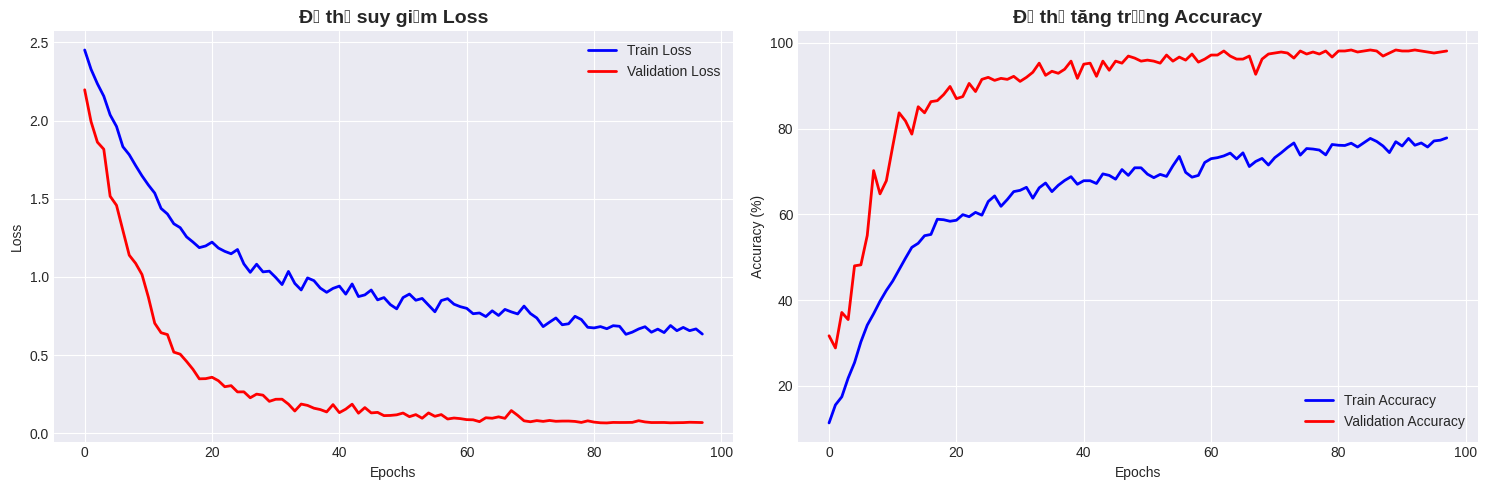

In [11]:
# ==========================================
# CELL 6: VẼ BIỂU ĐỒ TRỰC QUAN HÓA
# ==========================================

plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ Mất mát (Loss)
ax1.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(history['val_loss'], label='Validation Loss', color='red', linewidth=2)
ax1.set_title('Đồ thị suy giảm Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Biểu đồ Độ chính xác (Accuracy)
ax2.plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
ax2.plot(history['val_acc'], label='Validation Accuracy', color='red', linewidth=2)
ax2.set_title('Đồ thị tăng trưởng Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

🔎 ĐANG CHẠY PHÂN TÍCH ĐÁNH GIÁ TRÊN TẬP VALIDATION (DỮ LIỆU SẠCH 100%)...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7921 (\N{LATIN SMALL LETTER U WITH HORN AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7853 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7847 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarnin

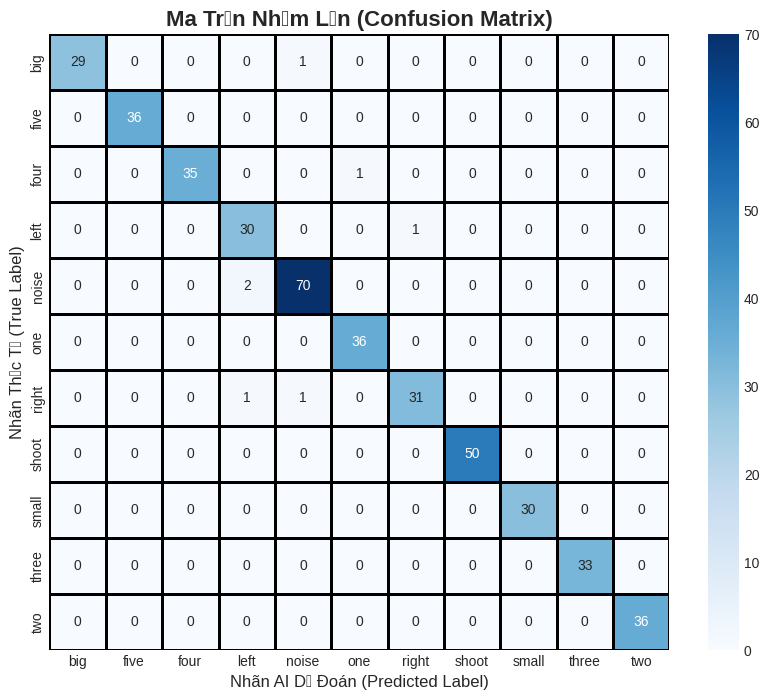


BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

         big       1.00      0.97      0.98        30
        five       1.00      1.00      1.00        36
        four       1.00      0.97      0.99        36
        left       0.91      0.97      0.94        31
       noise       0.97      0.97      0.97        72
         one       0.97      1.00      0.99        36
       right       0.97      0.94      0.95        33
       shoot       1.00      1.00      1.00        50
       small       1.00      1.00      1.00        30
       three       1.00      1.00      1.00        33
         two       1.00      1.00      1.00        36

    accuracy                           0.98       423
   macro avg       0.98      0.98      0.98       423
weighted avg       0.98      0.98      0.98       423

💡 HƯỚNG DẪN ĐỌC BÁO CÁO:
- Precision: AI dự đoán từ đó thì đúng được bao nhiêu % (Độ tin cậy).
- Recall: Trong tổng số từ đó ngoài đời 

In [12]:
# ==========================================
# CELL 7: ĐÁNH GIÁ CHUYÊN SÂU (CONFUSION MATRIX)
# ==========================================
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

print("🔎 ĐANG CHẠY PHÂN TÍCH ĐÁNH GIÁ TRÊN TẬP VALIDATION (DỮ LIỆU SẠCH 100%)...")

# Đảm bảo dùng mô hình tốt nhất đã lưu
model.load_state_dict(torch.load(SAVE_PATH)['model_state_dict'])
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        inputs = inputs.unsqueeze(1) # Thêm dimension Channel

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # Đẩy dữ liệu từ GPU về CPU để dùng với sklearn
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 1. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=1, linecolor='black')
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix)', fontsize=16, fontweight='bold')
plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12)
plt.xlabel('Nhãn AI Dự Đoán (Predicted Label)', fontsize=12)
plt.show()

# 2. In báo cáo chi tiết (Precision, Recall, F1-Score)
print("\n" + "="*50)
print("BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT)")
print("="*50)
report = classification_report(y_true, y_pred, target_names=classes)
print(report)

print("💡 HƯỚNG DẪN ĐỌC BÁO CÁO:")
print("- Precision: AI dự đoán từ đó thì đúng được bao nhiêu % (Độ tin cậy).")
print("- Recall: Trong tổng số từ đó ngoài đời thực, AI bắt được bao nhiêu % (Độ nhạy).")
print("- F1-score: Điểm cân bằng. Lớn hơn 0.90 là mô hình cực kỳ xuất sắc!")